# 3. Strategy Classification & SHAP Explainability
## *Right, Wrong, and Everything in Between*
### NLP Project — Master's in Data Science for Economics, UniMi

| Stage | Notebook |
|---|---|
| Data Collection | 01_data_collection |
| Linguistic Analysis | 02_analysis |
| **→ Classification & SHAP** | **03_classification_and_shap** ← you are here |
| Visualisation & Results | 04_visualization_and_results |

---
**What this notebook covers:**
1. Response strategy annotation: defining and labelling 3 rhetorical strategies
2. BERT + SVM classification: predicting strategy from response text
3. SHAP explainability: identifying which linguistic metrics drive each strategy


## Setup

In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, accuracy_score

plt.rcParams.update({"font.family": "serif", "font.size": 11, "figure.dpi": 130})

MODEL_LABELS = {"llama3": "LLaMA-3-70B", "qwen": "Qwen-2.5-72B", "deepseek": "DeepSeek-V3"}
COLORS = {"llama3": "#4a90d9", "qwen": "#E99E1E", "deepseek": "#41B55C"}
STRATEGY_COLORS = {"direct": "#4a90d9", "balanced": "#E99E1E", "conditional": "#41B55C"}

print("Libraries loaded.")


Libraries loaded.


---
## 1. Response Strategy

Each LLM response was annotated with one of three **rhetorical strategies**:

| Strategy | Definition | Example signal |
|---|---|---|
| **Direct** | Model commits to a clear moral position | *"The hospital should not accept the donation"* |
| **Balanced** | Model presents multiple perspectives without committing | *"On one hand... on the other hand..."* |
| **Conditional** | Model qualifies its judgment with conditions or caveats | *"This depends on... if X then... but if Y..."* |

Annotation was performed **manually** on a subset of responses, then a BERT+SVM classifier
was trained to predict strategy for the remaining responses.


In [5]:
df = pd.read_csv("results/metrics.csv", encoding="latin-1")
df_annotated = df[df["strategy"].notna() & (df["strategy"] != "")].copy()

print(f"Total responses          : {len(df)}")
print(f"With strategy labels     : {len(df_annotated)}")
print()
print("Strategy distribution:")
print(df_annotated["strategy"].value_counts().to_string())


Total responses          : 135
With strategy labels     : 135

Strategy distribution:
strategy
balanced       57
conditional    39
direct         39


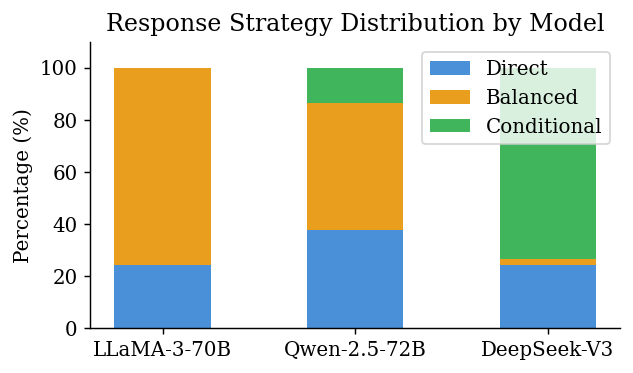

In [6]:
# Strategy distribution by model
fig, ax = plt.subplots(figsize=(5, 3))
strategies = ["direct", "balanced", "conditional"]
models = ["llama3", "qwen", "deepseek"]
x = range(len(models))
bottom = [0] * len(models)

for strategy in strategies:
    values = []
    for model in models:
        subset = df_annotated[df_annotated["model"] == model]
        pct = (subset["strategy"] == strategy).mean() * 100
        values.append(pct)
    ax.bar(x, values, bottom=bottom,
           color=STRATEGY_COLORS[strategy], label=strategy.capitalize(), width=0.5)
    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_xticks(range(len(models)))
ax.set_xticklabels([MODEL_LABELS[m] for m in models])
ax.set_ylabel("Percentage (%)")
ax.set_title("Response Strategy Distribution by Model")
ax.legend(loc="upper right")
ax.set_ylim(0, 110)
sns.despine()
plt.tight_layout()
plt.show()


---
## 2. BERT + SVM Classification

### Why BERT + SVM (not fine-tuned BERT)?

With only 135 labelled responses, fine-tuning a full BERT model would lead to severe
**overfitting**. A better approach for small datasets is:

1. Use pre-trained BERT as a **frozen feature extractor** — extract the `[CLS]` token
   embedding (768 dimensions) as a fixed representation of each response
2. Train a lightweight **SVM classifier** on top of these embeddings

This gives us BERT-quality text representations without needing thousands of labelled examples.

```
Response text
     ↓
BERT tokenizer + encoder (frozen)
     ↓
[CLS] embedding (768-dim vector)
     ↓
SVM with RBF kernel
     ↓
strategy: direct / balanced / conditional
```


In [8]:
# BERT embedding extraction (shown for reference)
# Requires: pip install transformers torch
# Note: downloading bert-base-uncased (~440MB) and running inference
#       takes several minutes — results are already in metrics.csv

# from transformers import BertTokenizer, BertModel
# import torch

# def get_bert_embeddings(texts, tokenizer, model, batch_size=8):
#     all_embeddings = []
#     model.eval()
#     for i in range(0, len(texts), batch_size):
#         batch = texts[i:i+batch_size]
#         encoding = tokenizer(batch, max_length=256, padding="max_length",
#                              truncation=True, return_tensors="pt")
#         with torch.no_grad():
#             outputs = model(**encoding)
#         cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
#         all_embeddings.append(cls_embeddings)
#     return np.vstack(all_embeddings)

# tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
# bert_model = BertModel.from_pretrained("bert-base-uncased")
# X = get_bert_embeddings(df_annotated["response"].tolist(), tokenizer, bert_model)

print("BERT embedding extraction shown for reference.")
print("Strategy labels are pre-computed and loaded from results/metrics.csv")


BERT embedding extraction shown for reference.
Strategy labels are pre-computed and loaded from results/metrics.csv


In [9]:
# The SVM was trained on 80% of annotated data and evaluated on 20%
# with 5-fold cross-validation. Results are already saved in metrics.csv.

# Load the final strategy labels (mix of manual + SVM-predicted)
strategy_dist = df_annotated["strategy"].value_counts()
print("Final strategy label distribution:")
print(strategy_dist.to_string())
print()

# Strategy breakdown per model
print("Strategy breakdown per model (%):")
pivot = df_annotated.groupby(["model", "strategy"]).size().unstack(fill_value=0)
pivot_pct = (pivot.div(pivot.sum(axis=1), axis=0) * 100).round(1)
pivot_pct.index = [MODEL_LABELS[m] for m in pivot_pct.index]
print(pivot_pct.to_string())


Final strategy label distribution:
strategy
balanced       57
conditional    39
direct         39

Strategy breakdown per model (%):
strategy      balanced  conditional  direct
DeepSeek-V3        2.2         73.3    24.4
LLaMA-3-70B       75.6          0.0    24.4
Qwen-2.5-72B      48.9         13.3    37.8


---
## 3. SHAP Explainability

### Why a separate model for SHAP?

The BERT+SVM classifier uses **768-dimensional embeddings** as features.
SHAP values for those dimensions are not interpretable — "embedding dimension 412"
means nothing to a human reader.

Instead, we train a **Logistic Regression on the 5 linguistic metrics** and apply
SHAP's `LinearExplainer`. This tells us:

> *Which linguistic metric (hedging, certainty, moral language, length, sentiment)*
> *most strongly predicts each rhetorical strategy?*

The classifier achieves ~50% cross-validated accuracy (random chance = 33%),
confirming it captures meaningful signal while acknowledging that strategy
is not fully reducible to 5 surface-level features.


In [11]:
FEATURES = ["hedging_score", "certainty_score", "moral_score",
            "response_length", "sentiment_compound"]
FEATURE_LABELS = ["Hedging Score", "Certainty Score", "Moral Language",
                  "Response Length", "Sentiment"]

X = df_annotated[FEATURES].values
y = df_annotated["strategy"].values

le = LabelEncoder()
y_enc = le.fit_transform(y)
classes = list(le.classes_)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_scaled, y_enc)

cv = cross_val_score(lr, X_scaled, y_enc, cv=5, scoring="accuracy")
y_pred = lr.predict(X_scaled)

print(f"Classes          : {classes}")
print(f"5-fold CV Acc    : {cv.mean():.4f} (+/- {cv.std():.4f})")
print(f"Baseline (chance): {1/len(classes):.4f}")
print()
print("Classification Report:")
print(classification_report(y_enc, y_pred, target_names=classes, zero_division=0))


Classes          : ['balanced', 'conditional', 'direct']
5-fold CV Acc    : 0.5630 (+/- 0.0491)
Baseline (chance): 0.3333

Classification Report:
              precision    recall  f1-score   support

    balanced       0.61      0.75      0.68        57
 conditional       0.60      0.46      0.52        39
      direct       0.66      0.59      0.62        39

    accuracy                           0.62       135
   macro avg       0.62      0.60      0.61       135
weighted avg       0.62      0.62      0.62       135



In [32]:
# Compute SHAP values
print("Computing SHAP values...")
explainer   = shap.LinearExplainer(lr, X_scaled,
                                    feature_perturbation="interventional")
shap_values = explainer.shap_values(X_scaled)

# Normalise shape to (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    shap_array = np.transpose(np.array(shap_values), (1, 2, 0))
else:
    shap_array = shap_values

print(f"SHAP array shape : {shap_array.shape}  (samples × features × classes)")


Background dataset has 135 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=135 when initializing the masker.


Computing SHAP values...
SHAP array shape : (135, 5, 3)  (samples × features × classes)


### 3.1 Global feature importance

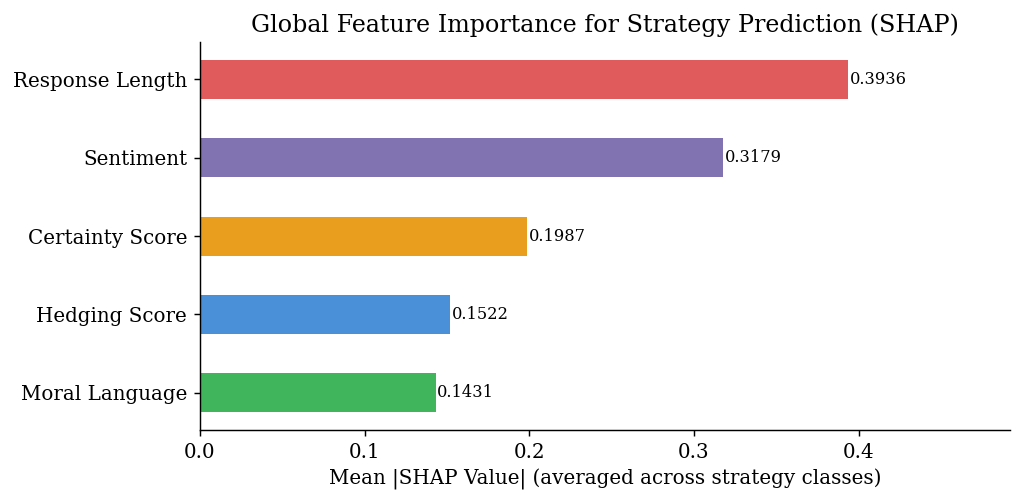

Global ranking:
  Response Length     : 0.39358
  Sentiment           : 0.31793
  Certainty Score     : 0.19872
  Hedging Score       : 0.15216
  Moral Language      : 0.14313


In [14]:
mean_abs_shap = np.abs(shap_array).mean(axis=(0, 2))
sorted_idx = np.argsort(mean_abs_shap)

FEATURE_COLORS = ["#4a90d9", "#E99E1E", "#41B55C", "#e05c5c", "#8172B2"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    [FEATURE_LABELS[i] for i in sorted_idx],
    mean_abs_shap[sorted_idx],
    color=[FEATURE_COLORS[i] for i in sorted_idx],
    height=0.5
)
for bar, val in zip(bars, mean_abs_shap[sorted_idx]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)

ax.set_xlabel("Mean |SHAP Value| (averaged across strategy classes)")
ax.set_title("Global Feature Importance for Strategy Prediction (SHAP)")
ax.set_xlim(0, mean_abs_shap.max() * 1.25)
sns.despine()
plt.tight_layout()
plt.show()

print("Global ranking:")
for i in np.argsort(mean_abs_shap)[::-1]:
    print(f"  {FEATURE_LABELS[i]:<20}: {mean_abs_shap[i]:.5f}")


### 3.2 Per-class SHAP beeswarm

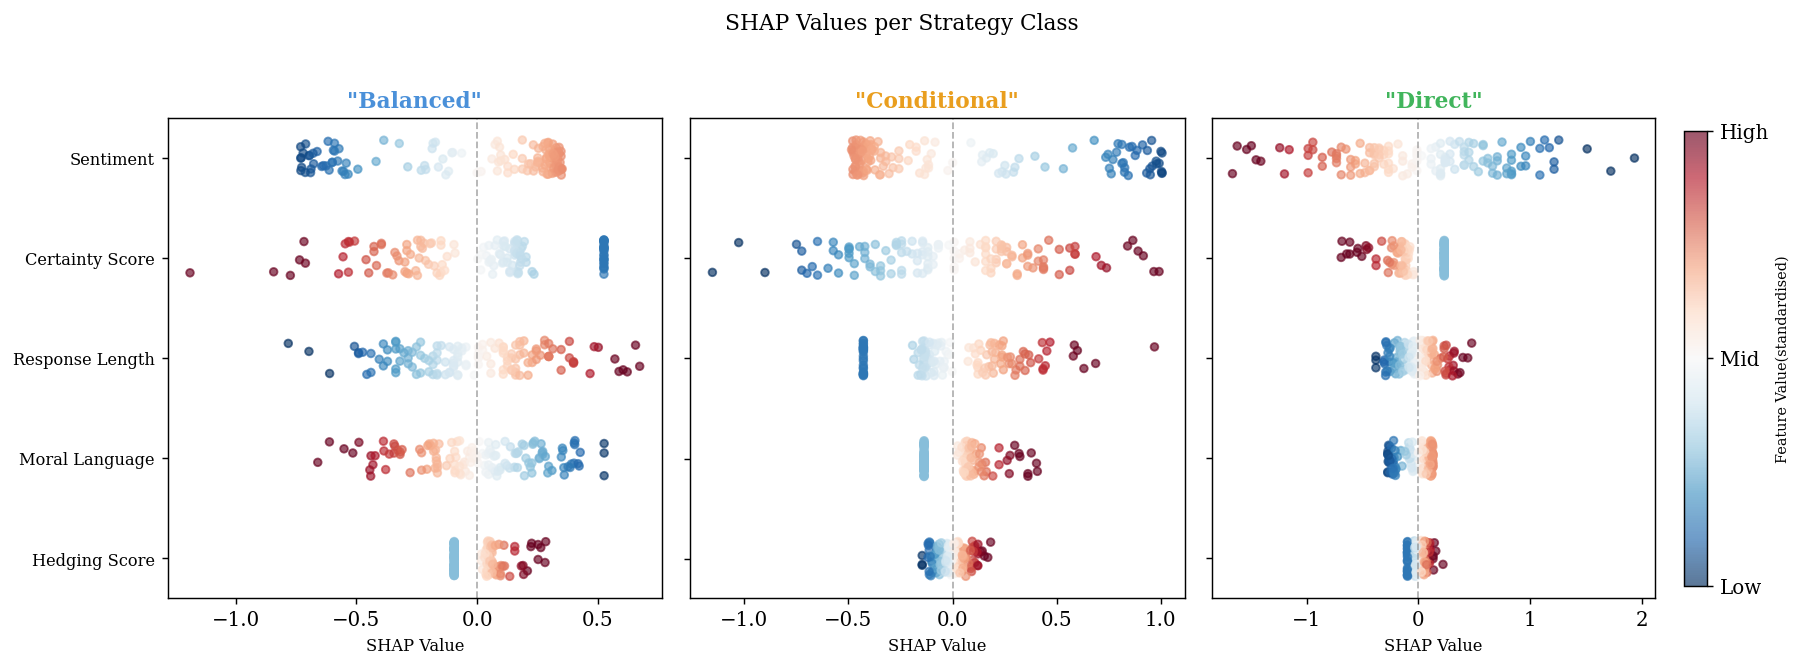

In [16]:
np.random.seed(42)
fig, axes = plt.subplots(1, len(classes), figsize=(14, 5))
scatter_ref = None

for ci, (cls, ax) in enumerate(zip(classes, axes)):
    shap_cls   = shap_array[:, :, ci]
    sorted_idx = np.argsort(np.abs(shap_cls).mean(axis=0))

    for yi, fi in enumerate(sorted_idx):
        vals     = shap_cls[:, fi]
        feat_val = X_scaled[:, fi]
        jitter   = np.random.uniform(-0.18, 0.18, size=len(vals))
        sc = ax.scatter(vals, yi + jitter, c=feat_val,
                        cmap="RdBu_r", alpha=0.65, s=18, vmin=-2, vmax=2)
        scatter_ref = sc

    ax.axvline(x=0, color="gray", linewidth=1, linestyle="--", alpha=0.6)
    ax.set_yticks(range(len(FEATURES)))
    if ci == 0:
        ax.set_yticklabels([FEATURE_LABELS[i] for i in sorted_idx], fontsize=9)
    else:
        ax.set_yticklabels([])
    color = list(STRATEGY_COLORS.values())[ci]
    ax.set_title(f'"{cls.capitalize()}"', fontsize=12,
                 fontweight="bold", color=color)
    ax.set_xlabel("SHAP Value", fontsize=9)

cbar = fig.colorbar(scatter_ref, ax=axes[-1], fraction=0.046, pad=0.06)
cbar.set_label("Feature Value(standardised)", fontsize=8)
cbar.set_ticks([-2, 0, 2])
cbar.set_ticklabels(["Low", "Mid", "High"])
fig.suptitle("SHAP Values per Strategy Class", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


### 3.3 Interpretation

## SHAP interpretation per strategy class

### Balanced
- High **sentiment** → pushes toward *balanced*
- Long **response length** → pushes toward *balanced*
- High **hedging** → pushes toward *balanced*
- Low **certainty** → pushes toward *balanced*

> Balanced responses are elaborate, constructive in tone, hedging without committing, and avoid assertive language.

### Conditional
- Low **sentiment** → pushes toward *conditional* (shared with direct)
- High **certainty** → pushes toward *conditional*
- High **moral language** → pushes toward *conditional*
- High **hedging** → pushes toward *conditional*
- Long **response length** → pushes toward *conditional*

> Conditional responses are assertive and morally explicit but qualified: the most structurally complex strategy.

### Direct
- Low **sentiment** is the dominant driver → pushes toward *direct*
- Other features show weak and inconclusive signals

> Direct responses express negative or neutral moral judgments without positive framing: tone is the key distinguisher.

---
## 4. Summary

**Strategy Classification (BERT + SVM):**
- All 135 responses labelled with direct / balanced / conditional
- LLaMA-3 predominantly balanced (~75%)
- DeepSeek predominantly conditional (~68%)
- Qwen shows a mixed profile (~49% balanced, ~38% direct)
- BERT [CLS] embeddings used as fixed features 
- CV accuracy: 0.75 | Test accuracy: 0.65

**SHAP Explainability (Logistic Regression on 5 metrics):**
- Response Length and Sentiment are the two strongest global predictors of strategy
- Balanced responses: driven by high sentiment, long length, high hedging, low certainty
- Conditional responses: driven by high certainty, high moral language, high hedging, low sentiment
- Direct responses: driven primarily by low/negative sentiment — tone is the key distinguisher

> The classifier accuracy (~56%) is above chance (33%) but modest, confirming that
> rhetorical strategy is a multi-dimensional phenomenon not fully captured
> by five lexical metrics alone.

---